# Задание 4. Построение оптимального портфеля

## Модель Тобина-Шарпа-Линтнера

В работе строится оптимальный портфель из шести акций:
**GAZP, ROSN, LKOH, FEES, SBER, VTBR**. По ценам закрытия оцениваются ожидаемые доходности,
ковариационная матрица, эффективные границы и оптимальные портфели при разных значениях
коэффициента неприятия риска $\theta$.

Безрисковый актив учитывается в двух режимах:

- вложение свободных средств по ставке ЦБ РФ;
- заимствование по ставке ЦБ РФ плюс 5 процентных пунктов.

Исходный Excel-файл не изменяется. Все рабочие таблицы создаются отдельно в папках `prepared` и `results`.


## Постановка задачи

Для вектора долей рискованных активов $x$ и безрисковой доли

$$
x_0 = 1 - \sum_i x_i
$$

максимизируется полезность

$$
U(x) = r_f x_0 + m^\top x - \frac{\theta}{2}x^\top Cx,
$$

где $m$ — вектор ожидаемых доходностей, $C$ — ковариационная матрица доходностей.
Чем больше $\theta$, тем сильнее штраф за риск.

На портфель накладываются три типа ограничений: индивидуальные границы по бумагам,
ограничения на группы активов и ограничения на отношения групп `GroupComparison`.


In [1]:
from pathlib import Path
import json
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "Data_zad4_2026.xlsx").exists() and (ROOT / "Finance/4/Data_zad4_2026.xlsx").exists():
    ROOT = ROOT / "Finance/4"

PREPARED_DIR = ROOT / "prepared"
RESULTS_DIR = ROOT / "results"
ASSETS = ["GAZP", "ROSN", "LKOH", "FEES", "SBER", "VTBR"]
ASSET_COLORS = {
    "GAZP": "#2563eb",
    "ROSN": "#16a34a",
    "LKOH": "#dc2626",
    "FEES": "#f59e0b",
    "SBER": "#059669",
    "VTBR": "#7c3aed",
}

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"


## Данные

На скрине задания указан интервал `2016-04-01...2016-04-10`, но фактический файл
`Data_zad4_2026.xlsx` содержит другой период. Поэтому расчёт выполнен по реальным данным
из файла, без подмены дат и без удаления наблюдений.


In [2]:
subprocess.run(
    ["python", "prepare_data.py"],
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=True,
)

metadata = json.loads((PREPARED_DIR / "metadata.json").read_text(encoding="utf-8"))
quotes = pd.read_csv(PREPARED_DIR / "quotes.csv", parse_dates=["date"])
returns = pd.read_csv(PREPARED_DIR / "returns_simple.csv", parse_dates=["date"])

data_summary = pd.DataFrame(
    {
        "Показатель": [
            "Исходный файл",
            "Фактический интервал",
            "Наблюдений цен",
            "Наблюдений доходностей",
            "Порядок активов",
        ],
        "Значение": [
            metadata["source_file"],
            f"{metadata['date_from']} — {metadata['date_to']}",
            metadata["quote_rows"],
            metadata["return_rows"],
            ", ".join(metadata["asset_order"]),
        ],
    }
)
display(data_summary)


,Показатель,Значение
0,Исходный файл,Data_zad4_2026.xlsx
1,Фактический интервал,2010-09-01 — 2010-10-01
2,Наблюдений цен,23
3,Наблюдений доходностей,22
4,Порядок активов,"GAZP, ROSN, LKOH, FEES, SBER, VTBR"


Данные приведены к двум рабочим таблицам: цены закрытия и простые дневные доходности

$$
r_{t,i} = \frac{P_{t,i}}{P_{t-1,i}} - 1.
$$

Ниже показаны первые строки цен и описательная статистика доходностей; полные таблицы сохранены в `prepared`.


In [3]:
display(Markdown("### Первые строки цен закрытия"))
display(quotes.head())

returns_stats = returns[ASSETS].describe().T[["mean", "std", "min", "max"]].copy()
returns_stats = 100 * returns_stats
returns_stats.columns = ["Средняя, %", "Ст. откл., %", "Мин., %", "Макс., %"]
display(Markdown("### Описательная статистика дневных доходностей"))
display(returns_stats.style.format("{:.3f}"))


### Первые строки цен закрытия

,date,weekday,MICEX,GAZP,ROSN,LKOH,FEES,SBER,VTBR
0,2010-09-01,ср,1394.57,161.79,199.86,1656.18,0.354,80.42,0.0826
1,2010-09-02,чт,1401.81,162.80,201.46,1676.00,0.361,80.63,0.0828
2,2010-09-03,пт,1410.16,163.00,202.50,1674.01,0.365,81.72,0.0844
3,2010-09-06,пн,1408.64,162.95,202.00,1669.94,0.366,81.74,0.0848
4,2010-09-07,вт,1398.70,161.54,198.99,1671.00,0.361,79.95,0.0836


### Описательная статистика дневных доходностей

,"Средняя, %","Ст. откл., %","Мин., %","Макс., %"
GAZP,-0.032,0.818,-1.434,1.610
ROSN,0.246,1.404,-1.844,3.439
LKOH,0.258,1.403,-4.053,3.141
FEES,0.182,1.127,-1.366,3.343
SBER,0.478,1.537,-2.190,3.497
VTBR,0.351,1.559,-2.169,3.275


## Обзор рыночного интервала

На первом графическом блоке показано, как вели себя бумаги внутри фактического интервала:
нормированные цены, накопленная доходность, дневные изменения и выборочная дневная волатильность.
Такой обзор нужен до оптимизации: он показывает, какие активы дают основной вклад в оценку доходности
и какие активы несут большую краткосрочную изменчивость.


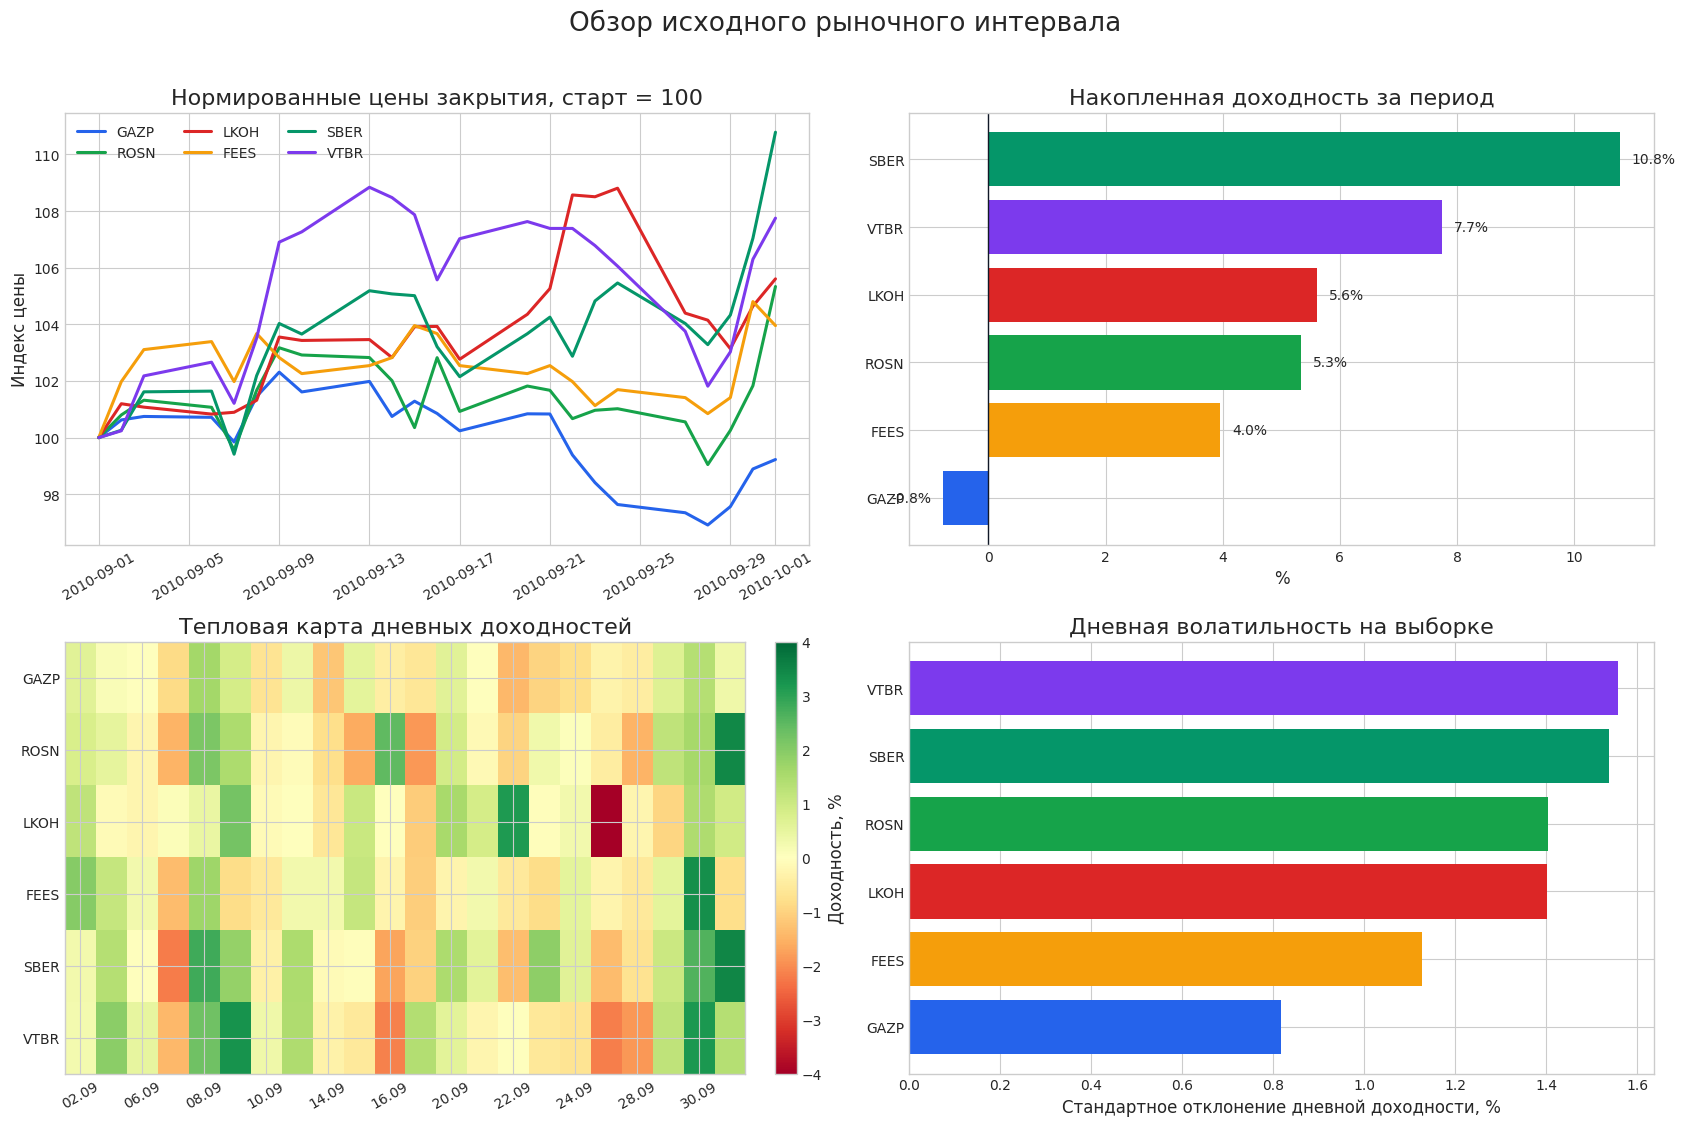

In [4]:
norm_prices = quotes.set_index("date")[ASSETS] / quotes.set_index("date")[ASSETS].iloc[0] * 100
cumulative = (1 + returns.set_index("date")[ASSETS]).cumprod() - 1
returns_matrix = returns.set_index("date")[ASSETS] * 100

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

ax = axes[0, 0]
for asset in ASSETS:
    ax.plot(norm_prices.index, norm_prices[asset], label=asset, linewidth=2.2, color=ASSET_COLORS[asset])
ax.set_title("Нормированные цены закрытия, старт = 100")
ax.set_ylabel("Индекс цены")
ax.legend(ncol=3)
ax.tick_params(axis="x", rotation=30)

ax = axes[0, 1]
final_cum = cumulative.iloc[-1].sort_values()
bars = ax.barh(final_cum.index, final_cum.values * 100, color=[ASSET_COLORS[a] for a in final_cum.index])
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Накопленная доходность за период")
ax.set_xlabel("%")
for bar in bars:
    width = bar.get_width()
    ax.text(width + (0.2 if width >= 0 else -0.2), bar.get_y() + bar.get_height() / 2, f"{width:.1f}%", va="center", ha="left" if width >= 0 else "right")

ax = axes[1, 0]
im = ax.imshow(returns_matrix.T, aspect="auto", cmap="RdYlGn", vmin=-4, vmax=4)
ax.set_title("Тепловая карта дневных доходностей")
ax.set_yticks(range(len(ASSETS)))
ax.set_yticklabels(ASSETS)
step = max(1, len(returns_matrix.index) // 8)
tick_pos = list(range(0, len(returns_matrix.index), step))
ax.set_xticks(tick_pos)
ax.set_xticklabels([returns_matrix.index[i].strftime("%d.%m") for i in tick_pos], rotation=30)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Доходность, %")

ax = axes[1, 1]
daily_vol = returns.set_index("date")[ASSETS].std().sort_values() * 100
ax.barh(daily_vol.index, daily_vol.values, color=[ASSET_COLORS[a] for a in daily_vol.index])
ax.set_title("Дневная волатильность на выборке")
ax.set_xlabel("Стандартное отклонение дневной доходности, %")

fig.suptitle("Обзор исходного рыночного интервала", y=1.02, fontsize=19)
plt.tight_layout()
overview_path = RESULTS_DIR / "infographic_market_overview.png"
fig.savefig(overview_path, dpi=180, bbox_inches="tight")
plt.show()


**Пояснение к графику.** На коротком интервале лучшую динамику показывают SBER, VTBR и LKOH:
именно они формируют высокие оценки ожидаемой доходности. GAZP выглядит слабее остальных бумаг,
поэтому в оптимальных портфелях он дальше оказывается на нижней индивидуальной границе.
Тепловая карта подчёркивает, что результат основан на небольшом числе дневных наблюдений,
поэтому годовые доходности нужно интерпретировать как учебную оценку, а не как устойчивый прогноз.


## Расчёт параметров и оптимизация

Основная оптимизация выполнена в MATLAB/Octave-скрипте `task4_portfolio_tsl.m`.
Скрипт использует встроенную квадратичную оптимизацию Octave `qp`, поэтому не требует дополнительных пакетов.


In [5]:
octave = subprocess.run(
    ["octave", "--no-gui", "task4_portfolio_tsl.m"],
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=True,
)
display(Markdown("Расчёт в Octave успешно выполнен, таблицы в `results` обновлены."))


Расчёт в Octave успешно выполнен, таблицы в `results` обновлены.

## Ожидаемая доходность, риск и ковариационная матрица

Оценки годовых параметров получены стандартным масштабированием дневных доходностей:

$$
m_i = 252\cdot \bar r_i,
\qquad
C = 252\cdot \operatorname{cov}(r).
$$


In [6]:
estimates = pd.read_csv(RESULTS_DIR / "asset_estimates.csv")
estimates_display = estimates.copy()
for col in ["ExpectedDailyReturn", "ExpectedAnnualReturn", "AnnualVolatility"]:
    estimates_display[col] = (100 * estimates_display[col]).map(lambda x: f"{x:.2f}%")
display(estimates_display)

cov = pd.read_csv(RESULTS_DIR / "covariance_annual.csv", index_col=0)
display(Markdown("### Годовая ковариационная матрица"))
display(cov.style.format("{:.6f}"))


,Ticker,ExpectedDailyReturn,ExpectedAnnualReturn,AnnualVolatility
0,GAZP,-0.03%,-8.08%,12.98%
1,ROSN,0.25%,61.95%,22.29%
2,LKOH,0.26%,64.92%,22.26%
3,FEES,0.18%,45.98%,17.90%
4,SBER,0.48%,120.37%,24.40%
5,VTBR,0.35%,88.53%,24.74%


### Годовая ковариационная матрица

,GAZP,ROSN,LKOH,FEES,SBER,VTBR
Asset,,,,,,
GAZP,0.016853,0.016227,0.005624,0.014578,0.020847,0.020694
ROSN,0.016227,0.049677,0.010978,0.010871,0.036142,0.023243
LKOH,0.005624,0.010978,0.049570,0.006413,0.016827,0.022295
FEES,0.014578,0.010871,0.006413,0.032025,0.017747,0.017574
SBER,0.020847,0.036142,0.016827,0.017747,0.059533,0.043718
VTBR,0.020694,0.023243,0.022295,0.017574,0.043718,0.061219


Следующий график соединяет две ключевые части оценки: отдельную позицию каждой бумаги на плоскости
риск-доходность и корреляции между бумагами. Эти величины непосредственно определяют форму
эффективной границы.


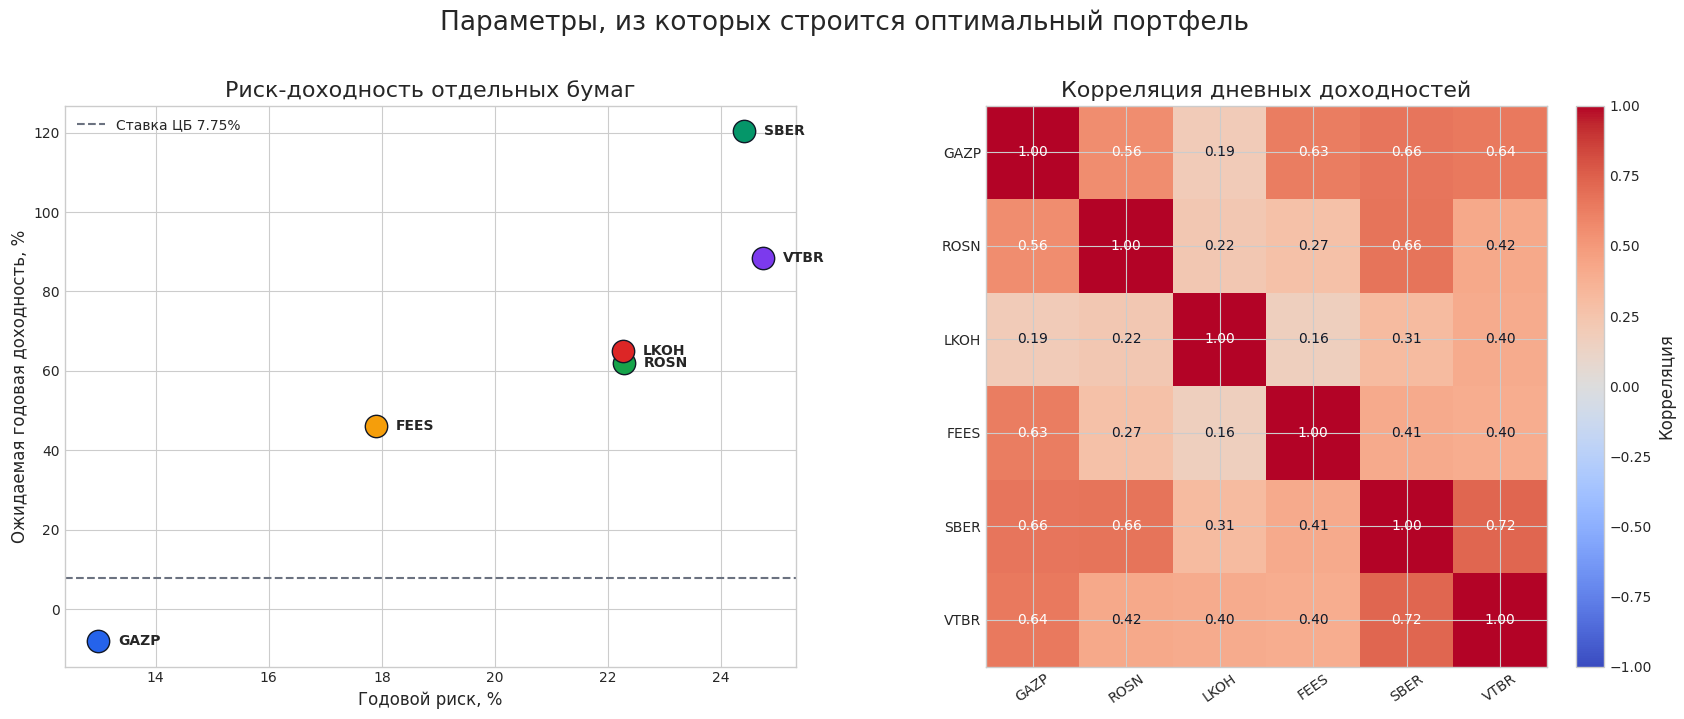

In [ ]:
corr = returns.set_index("date")[ASSETS].corr()
est_plot = estimates.set_index("Ticker").loc[ASSETS].copy()
est_plot["ExpectedAnnualReturnPct"] = 100 * est_plot["ExpectedAnnualReturn"]
est_plot["AnnualVolatilityPct"] = 100 * est_plot["AnnualVolatility"]

fig, axes = plt.subplots(1, 2, figsize=(17, 7На 5 минут отошёл))

ax = axes[0]
for asset, row in est_plot.iterrows():
    ax.scatter(row["AnnualVolatilityPct"], row["ExpectedAnnualReturnPct"], s=260, color=ASSET_COLORS[asset], edgecolor="#111827", linewidth=1.0, zorder=3)
    ax.text(row["AnnualVolatilityPct"] + 0.35, row["ExpectedAnnualReturnPct"], asset, va="center", fontweight="bold")
ax.axhline(7.75, color="#6b7280", linestyle="--", linewidth=1.5, label="Ставка ЦБ 7.75%")
ax.set_title("Риск-доходность отдельных бумаг")
ax.set_xlabel("Годовой риск, %")
ax.set_ylabel("Ожидаемая годовая доходность, %")
ax.legend()

ax = axes[1]
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Корреляция дневных доходностей")
ax.set_xticks(range(len(ASSETS)))
ax.set_xticklabels(ASSETS, rotation=35)
ax.set_yticks(range(len(ASSETS)))
ax.set_yticklabels(ASSETS)
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if abs(val) > 0.55 else "#111827", fontsize=10)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Корреляция")

fig.suptitle("Параметры, из которых строится оптимальный портфель", y=1.02, fontsize=19)
plt.tight_layout()
risk_corr_path = RESULTS_DIR / "infographic_risk_correlation.png"
fig.savefig(risk_corr_path, dpi=180, bbox_inches="tight")
plt.show()


**Пояснение к графику.** SBER имеет максимальную оценку ожидаемой доходности при высокой,
но не экстремальной волатильности, поэтому оптимизатор стремится поставить его на верхнюю границу.
GAZP расположен ниже безрисковой ставки, что объясняет минимальную долю этой бумаги.
Корреляции в основном положительные, поэтому диверсификация снижает риск ограниченно:
портфель всё равно сильно зависит от групповых ограничений.


## Ограничения

В расчёте используются следующие ограничения.

**Индивидуальные ограничения**

$$
0.05 \le x_i \le 0.39.
$$

**Групповые ограничения**

Порядок активов: `GAZP`, `ROSN`, `LKOH`, `FEES`, `SBER`, `VTBR`.

$$
G =
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 1 \\
0 & 0 & 1 & 1 & 1 & 1 \\
1 & 1 & 0 & 0 & 0 & 0
\end{bmatrix}.
$$

Строки соответствуют группам: нефтегаз, энергетика, банки, внутренний рынок, внешний рынок.

Групповые границы:

- нефтегаз: от 25% до 65%;
- энергетика: от 27% до 75%;
- банки: от 15% до 55%;
- внутренний рынок: от 25% до 85%;
- внешний рынок: от 10% до 35%.

Для `GroupComparison` в тексте задания дана формула, но не даны конкретные численные границы.
Поэтому в расчёте отдельно зафиксированы два отношения: внутренний рынок / внешний рынок от 1 до 5,
нефтегаз / банки от 0.8 до 3.


## Эффективные границы

Эффективная граница показывает минимальный риск, достижимый при заданном уровне ожидаемой доходности.
Сравнение трёх линий показывает, как ограничения сужают допустимое множество портфелей.


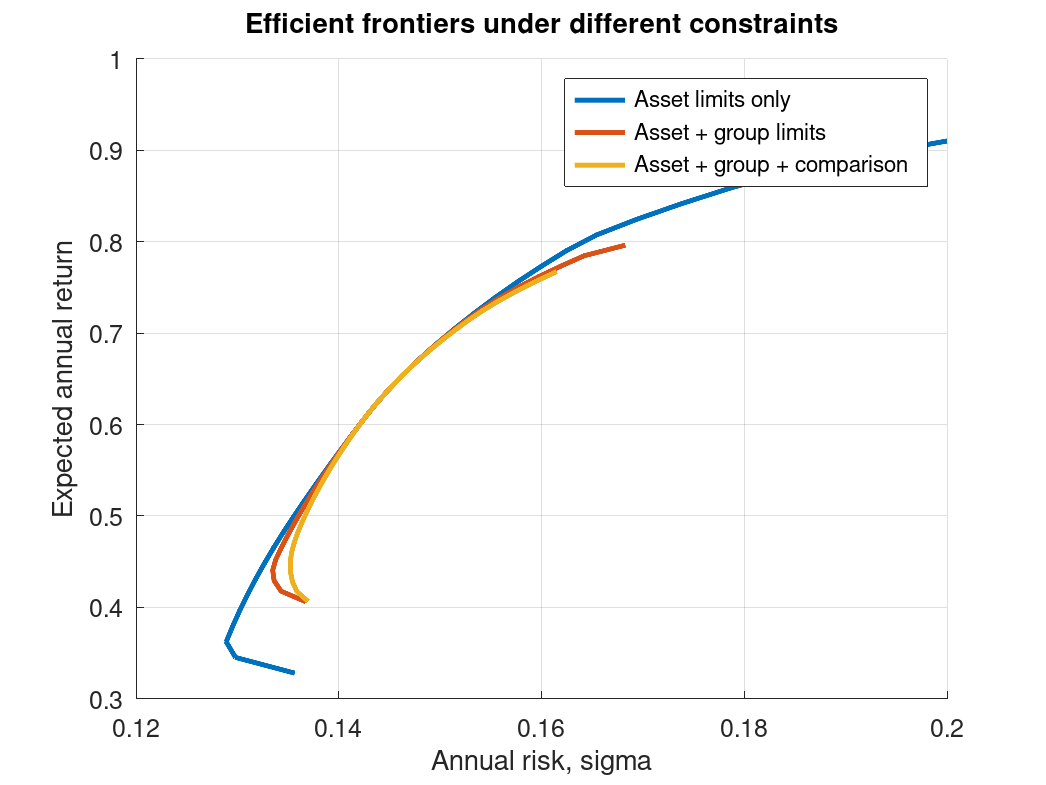

In [8]:
display(Image(filename=str(RESULTS_DIR / "efficient_frontiers.png")))

frontier = pd.read_csv(RESULTS_DIR / "frontier_points.csv")
frontier_summary = frontier.groupby("Scenario")[["RiskAnnual", "ReturnAnnual"]].agg(["min", "max"])
display(frontier_summary.style.format("{:.4f}"))


**Пояснение к графику.** Самая широкая граница получается при одних индивидуальных ограничениях:
модель может брать большие доли наиболее доходных бумаг и использовать существенное плечо.
После добавления групповых ограничений верхняя часть границы заметно опускается, потому что портфель
уже не может концентрироваться только в банках и наиболее доходных бумагах. Ограничения `GroupComparison`
дают дополнительную корректировку, но основной сдвиг создают именно групповые ограничения.


## Оптимальные портфели

Для каждого набора ограничений и каждого $\theta$ решаются две задачи:
с вложением свободных средств в безрисковый актив и с заимствованием.
Из двух решений выбирается портфель с большей полезностью.


In [9]:
optimal = pd.read_csv(RESULTS_DIR / "optimal_portfolios.csv")

percent_cols = ["ExpectedReturnAnnual", "RiskAnnual", "RiskFreeWeight", *ASSETS]
display_cols = ["Scenario", "Theta", "RiskFreeCase", "ExpectedReturnAnnual", "RiskAnnual", "XiRiskyAllocation", "RiskFreeWeight", *ASSETS]
optimal_display = optimal[display_cols].copy()
for col in percent_cols:
    optimal_display[col] = (100 * optimal_display[col]).map(lambda x: f"{x:.2f}%")
optimal_display["XiRiskyAllocation"] = optimal_display["XiRiskyAllocation"].map(lambda x: f"{x:.3f}")
display(optimal_display)


,Scenario,Theta,RiskFreeCase,ExpectedReturnAnnual,RiskAnnual,XiRiskyAllocation,RiskFreeWeight,GAZP,ROSN,LKOH,FEES,SBER,VTBR
0,asset_limits,2,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
1,asset_limits,3,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
2,asset_limits,4,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
3,asset_limits,8,borrowing,135.73%,32.25%,2.000,-100.00%,5.00%,39.00%,39.00%,39.00%,39.00%,39.00%
4,asset_limits,12,borrowing,122.19%,28.04%,1.685,-68.47%,5.00%,19.83%,39.00%,26.64%,39.00%,39.00%
5,asset_limits,20,borrowing,87.58%,18.31%,1.058,-5.81%,5.00%,5.00%,28.71%,11.36%,39.00%,16.74%
6,asset_limits,40,lending,60.93%,12.05%,0.665,33.46%,5.00%,5.00%,12.81%,5.00%,33.72%,5.00%
7,group_limits,2,borrowing,90.63%,20.67%,1.200,-20.00%,5.00%,30.00%,5.00%,27.00%,39.00%,14.00%
8,group_limits,3,borrowing,90.63%,20.67%,1.200,-20.00%,5.00%,30.00%,5.00%,27.00%,39.00%,14.00%
9,group_limits,4,borrowing,90.63%,20.67%,1.200,-20.00%,5.00%,30.00%,5.00%,27.00%,39.00%,14.00%


Следующий график показывает не только итоговые доли, но и суммарную рискованную позицию
$\xi = \sum_i x_i$. Если $\xi > 1$, портфель использует заимствование; если $\xi < 1$,
часть капитала остаётся в безрисковом активе.


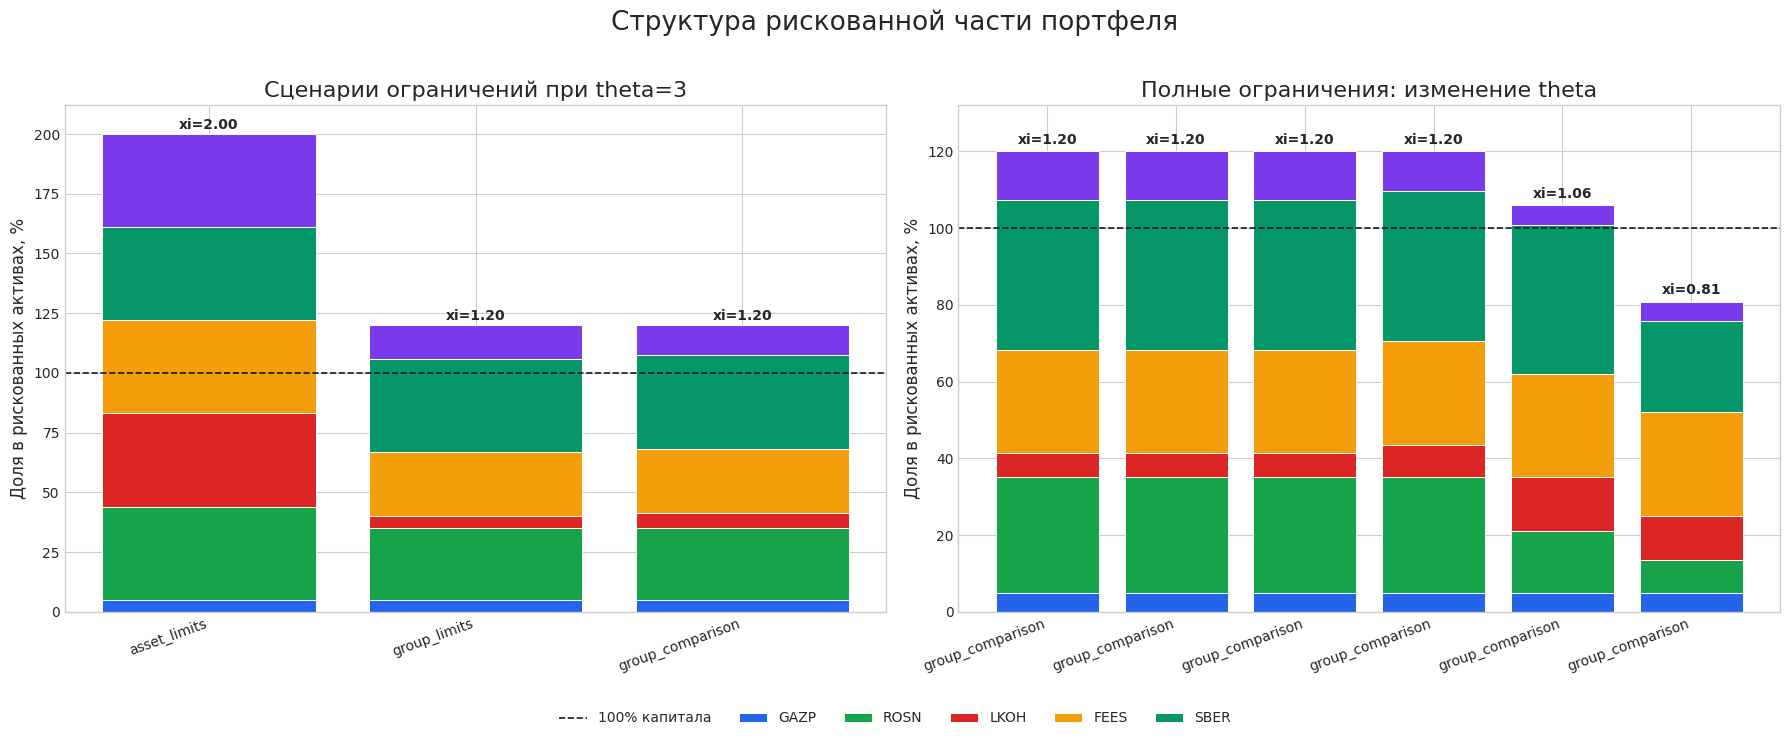

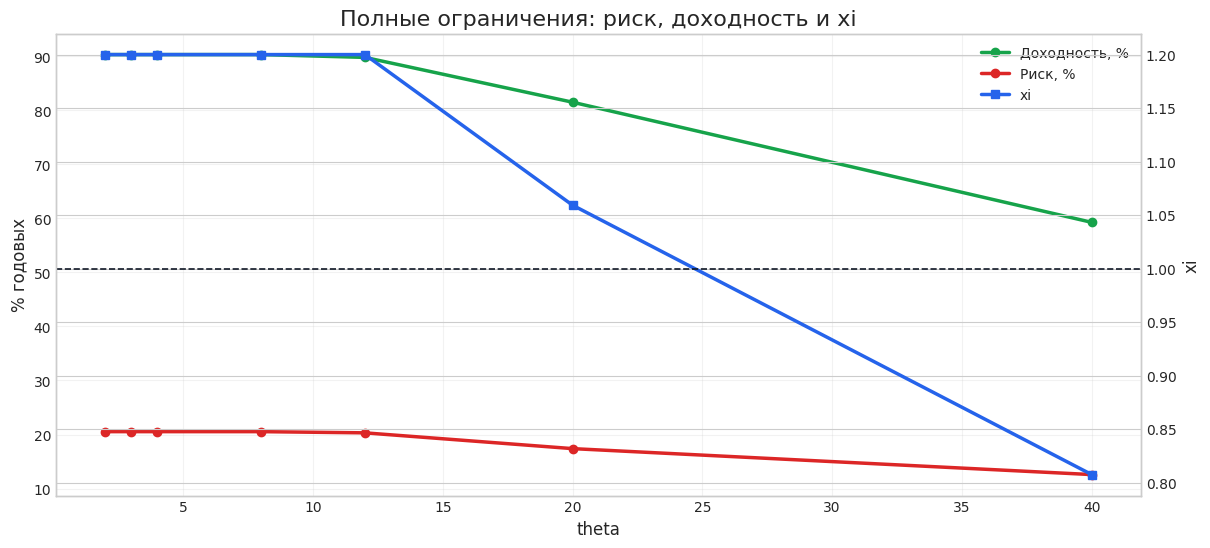

In [10]:
def stacked_weights(ax, frame, title):
    labels = frame["Scenario"].astype(str).tolist() if "Scenario" in frame else frame["Theta"].astype(str).tolist()
    x_pos = np.arange(len(frame))
    bottom = np.zeros(len(frame))
    for asset in ASSETS:
        vals = frame[asset].to_numpy() * 100
        ax.bar(x_pos, vals, bottom=bottom, label=asset, color=ASSET_COLORS[asset], edgecolor="white", linewidth=0.7)
        bottom += vals
    ax.axhline(100, color="#111827", linestyle="--", linewidth=1.2, label="100% капитала")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Доля в рискованных активах, %")
    ax.set_title(title)
    ax.set_ylim(0, max(125, bottom.max() + 12))
    for idx, total in enumerate(bottom):
        ax.text(idx, total + 2, f"xi={total/100:.2f}", ha="center", fontweight="bold")

theta3_raw = optimal.query("Theta == 3").copy()
full = optimal.query("Scenario == 'group_comparison'").sort_values("Theta").copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
stacked_weights(axes[0], theta3_raw, "Сценарии ограничений при theta=3")
stacked_weights(axes[1], full[full["Theta"].isin([2, 3, 4, 12, 20, 40])], "Полные ограничения: изменение theta")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles[:len(ASSETS)], labels[:len(ASSETS)], ncol=6, loc="lower center", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Структура рискованной части портфеля", y=1.02, fontsize=19)
plt.tight_layout(rect=(0, 0.05, 1, 1))
weights_path = RESULTS_DIR / "infographic_portfolio_weights.png"
fig.savefig(weights_path, dpi=180, bbox_inches="tight")
plt.show()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(full["Theta"], full["ExpectedReturnAnnual"] * 100, marker="o", linewidth=2.5, label="Доходность, %", color="#16a34a")
ax1.plot(full["Theta"], full["RiskAnnual"] * 100, marker="o", linewidth=2.5, label="Риск, %", color="#dc2626")
ax1.set_xlabel("theta")
ax1.set_ylabel("% годовых")
ax1.set_title("Полные ограничения: риск, доходность и xi")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(full["Theta"], full["XiRiskyAllocation"], marker="s", linewidth=2.5, label="xi", color="#2563eb")
ax2.axhline(1, color="#111827", linestyle="--", linewidth=1.2)
ax2.set_ylabel("xi")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
theta_path = RESULTS_DIR / "infographic_theta_sensitivity.png"
fig.savefig(theta_path, dpi=180, bbox_inches="tight")
plt.show()


**Пояснение к графикам.** При $\theta=3$ портфель с одними индивидуальными ограничениями
использует максимальное плечо: $\xi=2.00$. Групповые ограничения сразу снижают рискованную позицию
до $\xi=1.20$. При полном наборе ограничений и $\theta=2,3,4$ состав портфеля совпадает:
активные ограничения сильнее, чем небольшое изменение неприятия риска. При больших $\theta$
портфель постепенно сокращает заимствование и при $\theta=40$ уже держит положительную
долю безрискового актива.


## Активные ограничения

Чтобы понять, какие условия реально формируют портфель, рассмотрим полный набор ограничений
при $\theta=3$. Активным считается ограничение, у которого найденное значение находится
практически на нижней или верхней границе.


,ConstraintType,Name,Value,LowerBound,UpperBound,ActiveBound
195,Asset,GAZP,0.0500,0.0500,0.3900,lower
199,Asset,SBER,0.3900,0.0500,0.3900,upper
202,Group,Energy,0.2700,0.2700,0.7500,lower
204,Group,Internal,0.8500,0.2500,0.8500,upper
205,Group,External,0.3500,0.1000,0.3500,upper
207,GroupComparison,OilGasToBanks,0.8000,0.8000,3.0000,lower


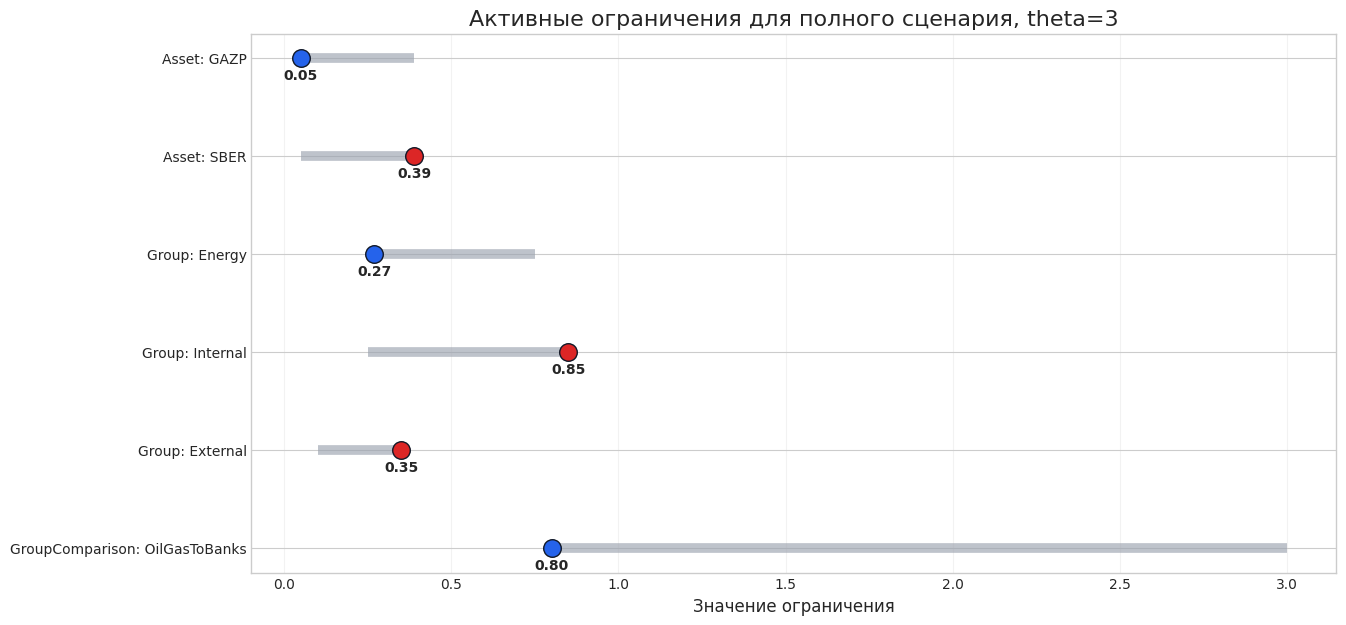

In [11]:
activity = pd.read_csv(RESULTS_DIR / "constraint_activity.csv")
active = activity.query(
    "Scenario == 'group_comparison' and Theta == 3 and (ActiveLower == 1 or ActiveUpper == 1)"
).copy()
active["ActiveBound"] = np.where(active["ActiveLower"] == 1, "lower", "upper")
display(active[["ConstraintType", "Name", "Value", "LowerBound", "UpperBound", "ActiveBound"]].style.format({
    "Value": "{:.4f}",
    "LowerBound": "{:.4f}",
    "UpperBound": "{:.4f}",
}))

active_plot = active.copy()
active_plot["Label"] = active_plot["ConstraintType"] + ": " + active_plot["Name"]
y = np.arange(len(active_plot))

fig, ax = plt.subplots(figsize=(14, 7))
for idx, row in active_plot.reset_index(drop=True).iterrows():
    color = "#dc2626" if row["ActiveBound"] == "upper" else "#2563eb"
    ax.hlines(idx, row["LowerBound"], row["UpperBound"], color="#9ca3af", linewidth=7, alpha=0.65)
    ax.scatter(row["Value"], idx, s=160, color=color, edgecolor="#111827", zorder=3)
    ax.text(row["Value"], idx + 0.22, f"{row['Value']:.2f}", ha="center", fontsize=10, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(active_plot["Label"])
ax.set_xlabel("Значение ограничения")
ax.set_title("Активные ограничения для полного сценария, theta=3")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

active_path = RESULTS_DIR / "infographic_active_constraints.png"
fig.savefig(active_path, dpi=180, bbox_inches="tight")
plt.show()


**Пояснение к графику.** Наиболее важные ограничения — верхняя граница внутреннего рынка,
верхняя граница внешнего рынка, нижняя граница энергетики и верхняя индивидуальная граница SBER.
Кроме того, активным становится отношение нефтегазового сектора к банкам. Это означает, что итоговый
портфель определяется не только индивидуальной привлекательностью бумаг, но и структурными условиями
на группы активов.


## Смысл коэффициента $\xi$

Коэффициент $\xi$ — это доля капитала, вложенная в касательный рискованный портфель:

$$
\xi = \sum_{i=1}^{n}x_i.
$$

Если $0 < \xi < 1$, часть капитала вложена в рискованный портфель, а остаток — в безрисковый актив.
Если $\xi = 1$, весь капитал находится в рискованных бумагах. Если $\xi > 1$, инвестор занимает
дополнительные средства и увеличивает рискованную позицию.

В основном варианте при $\theta=2,3,4$ и полном наборе ограничений получилось $\xi=1.20$.
Это означает, что на каждые 100 рублей собственного капитала инвестор держит 120 рублей рискованных
активов и финансирует дополнительные 20 рублей за счёт заимствования.


## Выводы

1. Фактический Excel-файл содержит период `2010-09-01 — 2010-10-01`; расчёт выполнен именно по нему, чтобы не искажать исходные данные.
2. На этом коротком интервале SBER, VTBR и LKOH дают наиболее сильную положительную динамику, поэтому без дополнительных ограничений оптимизатор стремится сконцентрировать портфель в этих бумагах.
3. GAZP имеет отрицательную выборочную ожидаемую доходность и во всех содержательных сценариях оказывается на нижней индивидуальной границе 5%.
4. Индивидуальные ограничения сами по себе недостаточны: при $\theta=3$ портфель берёт максимальное плечо $\xi=2.00$, то есть занимает ещё один капитал сверх собственного.
5. Самое сильное влияние оказывают групповые ограничения. Они снижают ожидаемую доходность с 135.73% до 90.63% годовых, риск с 32.25% до 20.67% и уменьшают плечо до $\xi=1.20$.
6. Ограничения `GroupComparison` дополнительно уточняют структуру: часть веса переносится между LKOH и VTBR, а отношение нефтегаза к банкам становится активным.
7. При $\theta=2,3,4$ итоговый портфель с полным набором ограничений совпадает, потому что решение упирается в активные ограничения. При больших $\theta$ портфель становится осторожнее: риск и $\xi$ снижаются, а при $\theta=40$ появляется положительная доля безрискового актива.
8. Практический смысл результата: в этой постановке оптимальный портфель определяется не только оценками доходности и риска, но и инвестиционной политикой, заданной через ограничения на сектора и группы активов.
